## 1. Import Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [58]:
df = pd.read_csv("cleaned_sales_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 3. Data Understanding

In [59]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 878503
Number of columns: 10


In [60]:
df.head()

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No),Total,Hour,Day
0,01-07-2020,15:07.9,1.029000e+14,0.396,7.6,sale,No,3.0096,9,Wednesday
1,01-07-2020,17:27.3,1.029000e+14,0.849,3.2,sale,No,2.7168,9,Wednesday
2,01-07-2020,17:33.9,1.029000e+14,0.409,7.6,sale,No,3.1084,9,Wednesday
3,01-07-2020,19:45.4,1.029000e+14,0.421,10.0,sale,No,4.2100,9,Wednesday
4,01-07-2020,20:23.7,1.029000e+14,0.539,8.0,sale,No,4.3120,9,Wednesday


In [64]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Date', 'Time', 'Item Code', 'Quantity Sold (kilo)', 'Unit Selling Price (RMB/kg)', 'Sale or Return', 'Discount (Yes/No)', 'Total', 'Hour', 'Day']


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878503 entries, 0 to 878502
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Date                         878503 non-null  object 
 1   Time                         878503 non-null  object 
 2   Item Code                    878503 non-null  float64
 3   Quantity Sold (kilo)         878503 non-null  float64
 4   Unit Selling Price (RMB/kg)  878503 non-null  float64
 5   Sale or Return               878503 non-null  object 
 6   Discount (Yes/No)            878503 non-null  object 
 7   Total                        878503 non-null  float64
 8   Hour                         878503 non-null  int64  
 9   Day                          878503 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 67.0+ MB


In [66]:
df.describe()

,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Total,Hour
count,8.785030e+05,878503.000000,878503.000000,878503.000000,878503.000000
mean,1.030313e+14,0.536112,8.917144,3.835805,14.408807
std,7.174861e+11,0.400087,6.311265,2.813984,3.666489
min,1.029000e+14,-9.082000,0.100000,-100.000000,8.000000
25%,1.029000e+14,0.290000,4.900000,2.210000,11.000000
50%,1.029000e+14,0.435000,7.900000,3.332000,15.000000
75%,1.029000e+14,0.742000,10.800000,4.791600,18.000000
max,1.069740e+14,160.000000,119.900000,944.000000,23.000000


In [67]:
df["Sale or Return"].value_counts()

Sale or Return
sale      878042
return       461
Name: count, dtype: int64

## 4. Data Preprocessing

In [11]:
ml_df = df[df["Sale or Return"] == "sale"].copy()

print("Original dataset:", df.shape)
print("ML dataset:", ml_df.shape)

Original dataset: (878503, 10)
ML dataset: (878042, 10)


In [12]:
ml_df["Sale or Return"].value_counts()

Sale or Return
sale    878042
Name: count, dtype: int64

In [13]:
print("Target variable: Total")
print(ml_df["Total"].describe())

Target variable: Total
count    878042.00000
mean          3.84039
std           2.80449
min           0.02010
25%           2.21000
50%           3.33400
75%           4.79160
max         944.00000
Name: Total, dtype: float64


In [14]:
print("Features and data types:")
print(ml_df.dtypes)

Features and data types:
Date                            object
Time                            object
Item Code                      float64
Quantity Sold (kilo)           float64
Unit Selling Price (RMB/kg)    float64
Sale or Return                  object
Discount (Yes/No)               object
Total                          float64
Hour                             int64
Day                             object
dtype: object


## 5. Feature Selection

In [16]:
X = ml_df[
    [
        "Item Code",
        "Quantity Sold (kilo)",
        "Unit Selling Price (RMB/kg)",
        "Hour"
    ]
]

y = ml_df["Total"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
      Item Code  Quantity Sold (kilo)  Unit Selling Price (RMB/kg)  Hour
0  1.029000e+14                 0.396                          7.6     9
1  1.029000e+14                 0.849                          3.2     9
2  1.029000e+14                 0.409                          7.6     9
3  1.029000e+14                 0.421                         10.0     9
4  1.029000e+14                 0.539                          8.0     9

Target (y):
0    3.0096
1    2.7168
2    3.1084
3    4.2100
4    4.3120
Name: Total, dtype: float64


## 6. Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (702433, 4)
Testing data: (175609, 4)


## 7. Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [20]:
y_pred_linear = linear_model.predict(X_test)

print("First 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred_linear[:10])

First 10 actual values:
[4.4286 3.507  6.678  4.9    3.21   3.5346 4.     0.9    4.906  6.912 ]

First 10 predicted values:
[3.84713277 3.84713277 3.84713277 3.84713277 3.84713277 3.84713277
 3.84713277 3.84713277 3.84713277 3.84713277]


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)


Linear Regression Results
-------------------------
MAE : 0.9455770204535293
MSE : 2.832042044426676
RMSE: 1.6828672093860157
R²  : 0.750777666356381


## 8. Decision Tree Regression

In [23]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Regression trained successfully!")
print("\nFirst 10 predictions:")
print(y_pred_tree[:10])

Decision Tree Regression trained successfully!

First 10 predictions:
[4.40886129 3.48489992 6.40055451 4.89391749 3.20670586 3.32018292
 4.00558767 0.9466626  4.92173847 7.13875176]


In [24]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regression Results")
print("--------------------------------")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)

Decision Tree Regression Results
--------------------------------
MAE : 0.08360249445860832
MSE : 3.26954374948243
RMSE: 1.808187974045406
R²  : 0.7122771094449349


## 9. Random Forest Regression

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regression trained successfully!")
print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

Random Forest Regression trained successfully!

First 10 predictions:
[4.36942923 3.48764299 6.48567508 4.89274584 3.20797099 3.31846998
 3.96761433 0.93927199 4.97267172 7.05795776]


In [42]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("---------------------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Results
---------------------------------
MAE : 0.06470725274522554
MSE : 3.4312918294962116
RMSE: 1.8523746460951713
R²  : 0.6980431279817219


## 10. Model Comparison

In [43]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf
    ],
    "MSE": [
        mse_linear,
        mse_tree,
        mse_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf
    ],
    "R²": [
        r2_linear,
        r2_tree,
        r2_rf
    ]
})

results

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.945577,2.832042,1.682867,0.750778
1,Decision Tree,0.083602,3.269544,1.808188,0.712277
2,Random Forest,0.064707,3.431292,1.852375,0.698043


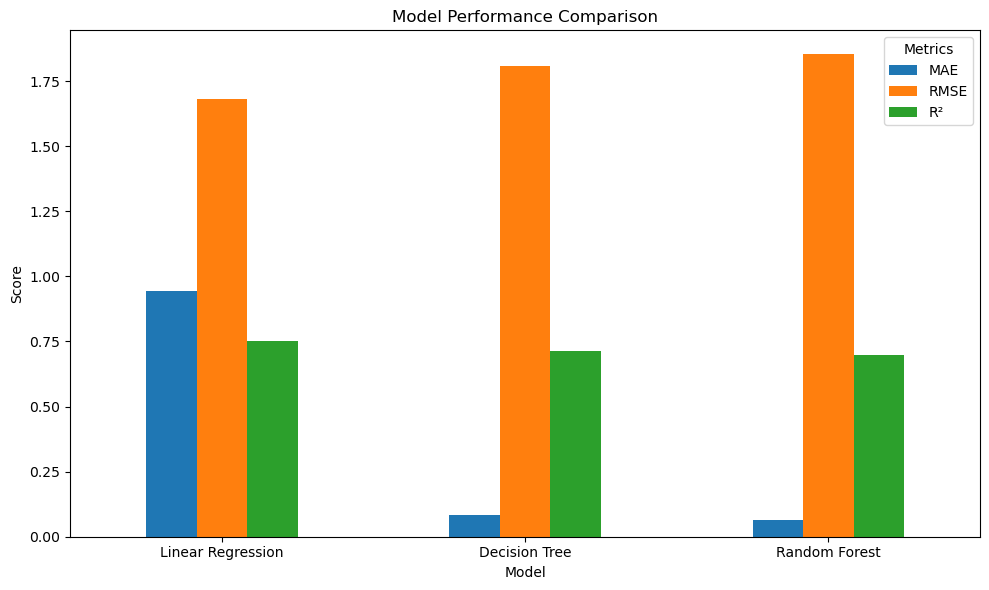

In [44]:
results.set_index("Model")[["MAE", "RMSE", "R²"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

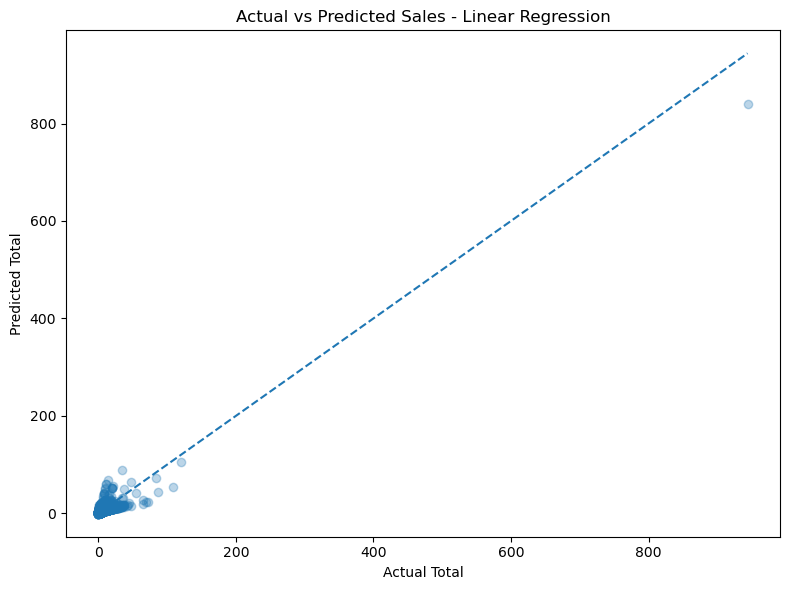

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.3)

plt.xlabel("Actual Total")
plt.ylabel("Predicted Total")
plt.title("Actual vs Predicted Sales - Linear Regression")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

## 11. Feature Importance

In [46]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                       Feature  Importance
1  Unit Selling Price (RMB/kg)    0.509208
0         Quantity Sold (kilo)    0.485811
2                         Hour    0.004981


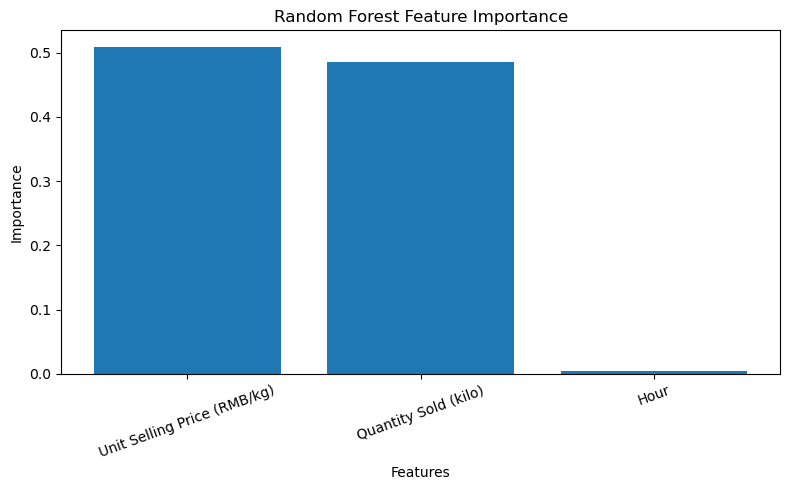

In [47]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 12. Save Models and Results

In [48]:
results.to_csv("model_comparison_results.csv", index=False)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!


In [49]:
import joblib

joblib.dump(rf_model, "random_forest_sales_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [50]:
joblib.dump(linear_model, "linear_regression_sales_model.pkl")

print("Linear Regression model saved successfully!")

Linear Regression model saved successfully!


In [51]:
joblib.dump(tree_model, "decision_tree_sales_model.pkl")

print("Decision Tree model saved successfully!")

Decision Tree model saved successfully!


In [52]:
ml_df.to_csv("ml_sales_data.csv", index=False)

print("ML dataset saved successfully!")

ML dataset saved successfully!


In [53]:
feature_importance.to_csv("feature_importance.csv", index=False)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [54]:
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_linear
})

prediction_results.head()

,Actual,Predicted
0,4.4286,4.006065
1,3.5070,3.225222
2,6.6780,6.139084
3,4.9000,5.112049
4,3.2100,3.035248


In [55]:
prediction_results.to_csv("linear_regression_predictions.csv", index=False)

print("Prediction results saved successfully!")

Prediction results saved successfully!


# Supermarket Sales Prediction Using Machine Learning

## Internship Project

This project focuses on predicting supermarket sales using machine learning regression techniques.

### Models Used
- Linear Regression
- Decision Tree Regression
- Random Forest Regression

### Evaluation Metrics
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R2 Score

## 13. Conclusion

This project developed a machine learning approach for predicting supermarket sales using historical sales data. Three regression models were trained and evaluated: Linear Regression, Decision Tree Regression, and Random Forest Regression.

The models were evaluated using MAE, MSE, RMSE, and R2 Score. Linear Regression achieved the highest R2 score in this experiment, while Random Forest achieved the lowest MAE.

Feature importance analysis showed that Unit Selling Price and Quantity Sold were the most influential features for the Random Forest model.

Overall, the project demonstrates how machine learning regression techniques can be applied to supermarket sales data for prediction and analysis.